# LeetCode #224: Basic Calculator

https://leetcode.com/problems/basic-calculator/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| Stack with Sign ★ | O(n) | O(n) |
| Recursive Descent | O(n) | O(n) |

## Understanding the Methods
### Stack with Sign (Optimal)
Track the current number, result, and sign. When encountering '(', push the current result and sign onto the stack, then reset. When encountering ')', pop the sign and previous result, and combine. This handles nested parentheses naturally without recursion.

### Recursive Descent
Parse the expression recursively: each level handles one pair of parentheses. More intuitive for some but uses the call stack, which behaves similarly to the explicit stack.

## Solutions

### C#

In [ ]:
public class Solution {
    public int Calculate(string s) {
        var stack = new Stack<int>();
        int result = 0, num = 0, sign = 1;
        foreach (char c in s) {
            if (char.IsDigit(c)) {
                num = num * 10 + (c - '0');
            } else if (c == '+') {
                result += sign * num;
                num = 0;
                sign = 1;
            } else if (c == '-') {
                result += sign * num;
                num = 0;
                sign = -1;
            } else if (c == '(') {
                stack.Push(result);
                stack.Push(sign);
                result = 0;
                sign = 1;
            } else if (c == ')') {
                result += sign * num;
                num = 0;
                result *= stack.Pop();
                result += stack.Pop();
            }
        }
        return result + sign * num;
    }
}

### Python

In [ ]:
class Solution:
    def calculate(self, s: str) -> int:
        stack = []
        result, num, sign = 0, 0, 1
        for c in s:
            if c.isdigit():
                num = num * 10 + int(c)
            elif c == '+':
                result += sign * num
                num = 0
                sign = 1
            elif c == '-':
                result += sign * num
                num = 0
                sign = -1
            elif c == '(':
                stack.append(result)
                stack.append(sign)
                result = 0
                sign = 1
            elif c == ')':
                result += sign * num
                num = 0
                result *= stack.pop()
                result += stack.pop()
        return result + sign * num

### Go

In [ ]:
func calculate(s string) int {
    stack := []int{}
    result, num, sign := 0, 0, 1
    for _, c := range s {
        switch {
        case c >= '0' && c <= '9':
            num = num*10 + int(c-'0')
        case c == '+':
            result += sign * num
            num = 0
            sign = 1
        case c == '-':
            result += sign * num
            num = 0
            sign = -1
        case c == '(':
            stack = append(stack, result, sign)
            result = 0
            sign = 1
        case c == ')':
            result += sign * num
            num = 0
            result *= stack[len(stack)-1]
            result += stack[len(stack)-2]
            stack = stack[:len(stack)-2]
        }
    }
    return result + sign*num
}

### Rust

In [ ]:
impl Solution {
    pub fn calculate(s: String) -> i32 {
        let mut stack: Vec<i32> = Vec::new();
        let (mut result, mut num, mut sign) = (0i64, 0i64, 1i64);
        for c in s.chars() {
            match c {
                '0'..='9' => num = num * 10 + (c as i64 - '0' as i64),
                '+' => { result += sign * num; num = 0; sign = 1; }
                '-' => { result += sign * num; num = 0; sign = -1; }
                '(' => {
                    stack.push(result as i32);
                    stack.push(sign as i32);
                    result = 0;
                    sign = 1;
                }
                ')' => {
                    result += sign * num;
                    num = 0;
                    result *= stack.pop().unwrap() as i64;
                    result += stack.pop().unwrap() as i64;
                }
                _ => {}
            }
        }
        (result + sign * num) as i32
    }
}

## Example Scenarios

### 1. Common Case — Simple Addition
**Input:** `s = "1 + 1"`

Parse '1', then '+' flushes $\text{result} += \text{sign} \times 1 = 1$ and resets num. Parse '1' again. At end, $\text{result} += \text{sign} \times \text{num} = 1 + 1 = 2$. Spaces are ignored.

WHY tricky: The final num must be added **after the loop ends** since there is no trailing operator to flush it. Forgetting this loses the last number.

$\text{result} = 0 + (+1)(1) + (+1)(1) = 2$. **Output:** `2`

---

### 2. Slightly Complex — Nested Parentheses
**Input:** `s = "(1+(4+5+2)-3)+(6+8)"`

Each '(' pushes current result and sign, then resets. Each ')' pops and combines: $\text{inner} \times \text{popped\_sign} + \text{popped\_result}$. Two nesting levels: inner $(4+5+2)=11$, outer $(1+11-3)=9$, then $+14 = 23$.

WHY tricky: Nested parentheses require the stack to **save/restore context**. The sign before '(' determines whether the inner result is added or subtracted from the outer context.

$= (1 + (4+5+2) - 3) + (6+8) = 9 + 14 = 23$. **Output:** `23`

---

### 3. Edge Case: Time — Deeply Nested Expression
**Input:** `s = "((((...(1+2)...))))"` (50,000 nested parentheses around "1+2", total $n \approx 10^5$ chars)

Each '(' pushes two values; each ')' pops two. With 50,000 nesting levels, the stack grows to 100,000 entries. The entire string is scanned once in $O(n)$ time.

WHY tricky: Maximum nesting depth $= n/2$ stresses stack operations. 50,000 push/pop pairs needed. The final result is still just 3, but the algorithm processes $\sim 10^5$ characters.

Stack: 50,000 pushes + 50,000 pops. Total: $O(n) = O(10^5)$. **Output:** `3`

---

### 4. Edge Case: Space — No Parentheses (Flat Expression)
**Input:** `s = "1 + 2 - 3 + 4 - 5 + 6 - 7 + 8 - 9 + 10"`

A flat expression with no parentheses. The stack is **never used** — it stays empty. Only three variables (result, num, sign) are needed. Left-to-right: $1+2-3+4-5+6-7+8-9+10 = 7$.

WHY tricky: Best case for space — $O(1)$ since the stack is never touched. The stack-based approach degrades gracefully to simple sequential evaluation.

Stack size $= 0$ throughout. Space $= O(1)$. **Output:** `7`

---

### 5. Almost Impossible — Nested Negation
**Input:** `s = "-(-(-(-(1))))"`

Four levels of negation. Each '-(' flips the sign. Four flips: $(-1)^4 = +1$. The innermost value 1 is multiplied by the cumulative sign $+1$, yielding 1. Even nesting depth gives positive result.

WHY tricky: The '-' before '(' sets $\text{sign} = -1$, then '(' pushes it. This chains through multiple levels. The pattern "-( " is different from "(-" — the minus belongs to the **outer** context and is pushed onto the stack.

$(-1)^4 \times 1 = 1$. Odd nesting would give $-1$. **Output:** `1`

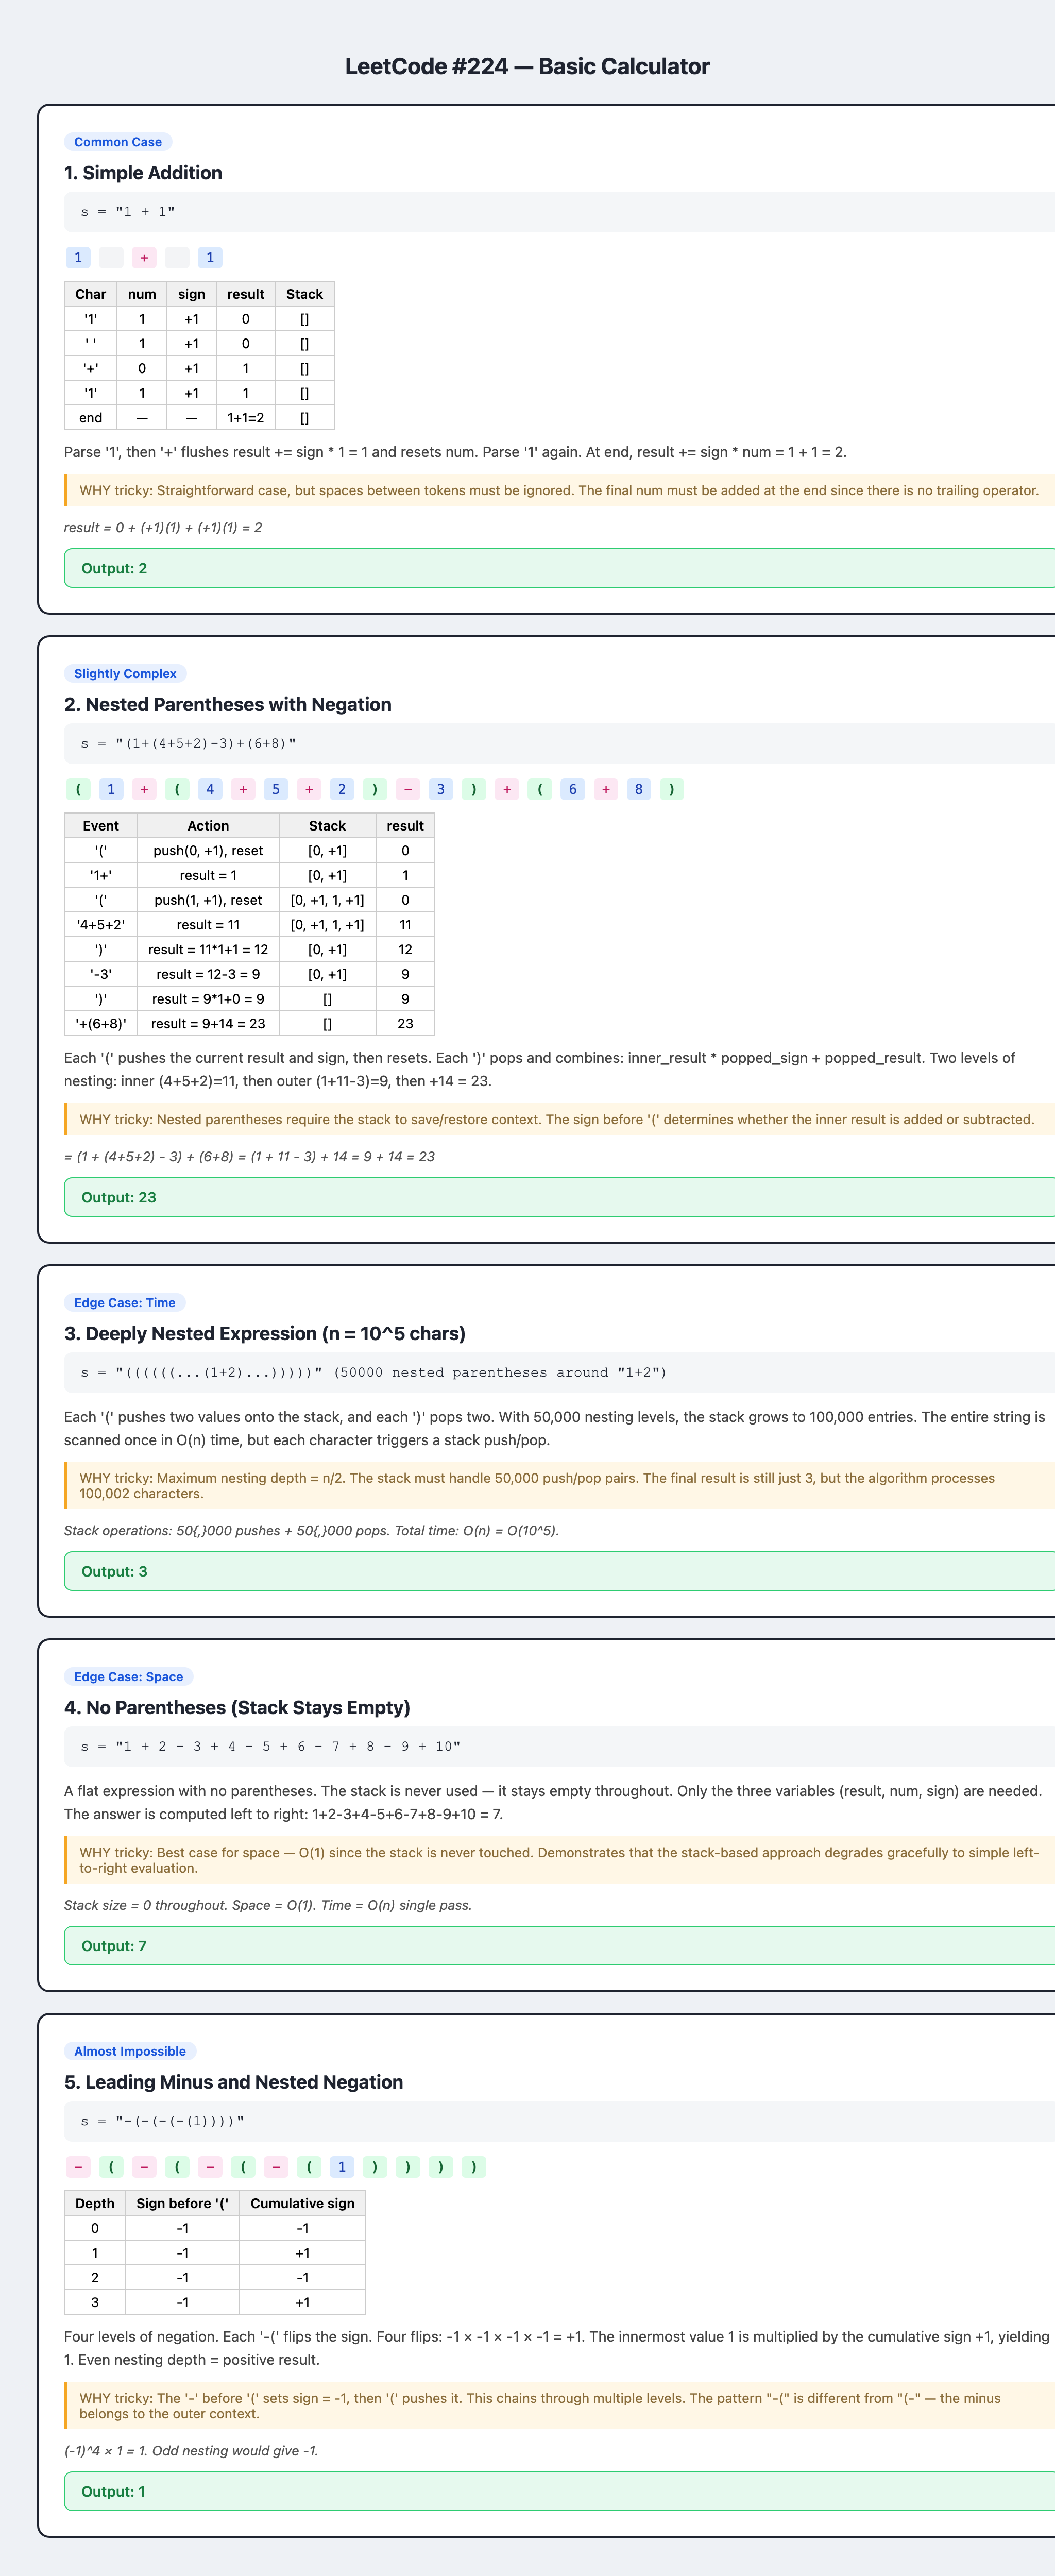